# Warden fuzzy: controlador Mamdani de priorizacao de alertas

Controlador fuzzy Mamdani, em [scikit-fuzzy](https://pythonhosted.org/scikit-fuzzy/),
que prioriza alertas de seguranca a partir de duas leituras que um SOC ja
coleta: a gravidade tecnica do indicador e a confianca de que ele e um
verdadeiro positivo.

## O dominio

Um analista de SOC recebe alertas continuamente e precisa decidir, na hora,
quais tratar primeiro. Duas leituras isoladas raramente bastam: um indicador
de severidade alta mas com baixa confianca (pode ser falso positivo de uma
regra ruidosa) nao deveria furar a fila na frente de um indicador de
severidade media com confianca alta (uma assinatura confirmada). O
controlador combina as duas em um unico score de prioridade continuo, em vez
de dois limiares independentes que ignoram essa interacao.

In [1]:
!pip install -q scikit-fuzzy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## Entradas e saida

| Variavel | Faixa | O que mede |
| --- | --- | --- |
| `severidade` | 0 a 10 | gravidade tecnica do indicador, estilo CVSS |
| `confianca` | 0 a 100 | confianca de que o alerta e verdadeiro positivo, nao ruido |
| `prioridade` (saida) | 0 a 10 | urgencia recomendada de tratamento |

In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

severidade = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "severidade")
confianca = ctrl.Antecedent(np.arange(0, 100.01, 1), "confianca")
prioridade = ctrl.Consequent(np.arange(0, 10.01, 0.1), "prioridade")

## Termos linguisticos

Tres termos por variavel (`baixa`, `media`, `alta`), o minimo que ainda
distingue as tres decisoes reais de uma fila de triagem: descartar ou revisar
depois, colocar na fila normal, ou acionar resposta imediata. Um quarto termo
adicionaria granularidade sem mudar nenhuma dessas tres decisoes.

Funcoes de pertinencia triangulares (`trimf`), cobrindo o dominio inteiro sem
lacunas: em qualquer ponto do eixo, pelo menos um termo tem pertinencia
maior que zero.

In [3]:
severidade["baixa"] = fuzz.trimf(severidade.universe, [0, 0, 5])
severidade["media"] = fuzz.trimf(severidade.universe, [0, 5, 10])
severidade["alta"] = fuzz.trimf(severidade.universe, [5, 10, 10])

confianca["baixa"] = fuzz.trimf(confianca.universe, [0, 0, 50])
confianca["media"] = fuzz.trimf(confianca.universe, [0, 50, 100])
confianca["alta"] = fuzz.trimf(confianca.universe, [50, 100, 100])

prioridade["baixa"] = fuzz.trimf(prioridade.universe, [0, 0, 5])
prioridade["media"] = fuzz.trimf(prioridade.universe, [0, 5, 10])
prioridade["alta"] = fuzz.trimf(prioridade.universe, [5, 10, 10])

/Users/romuloduarte/.pyenv/versions/3.13.6/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


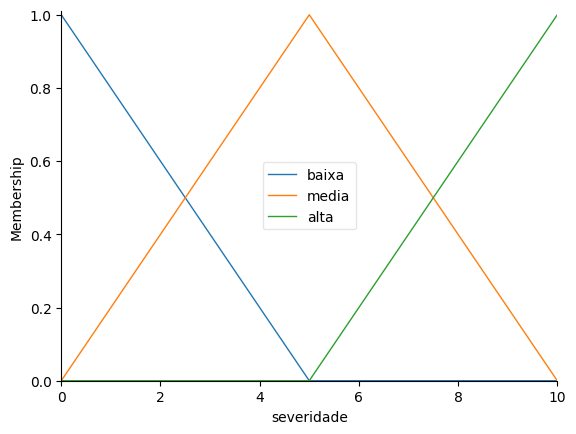

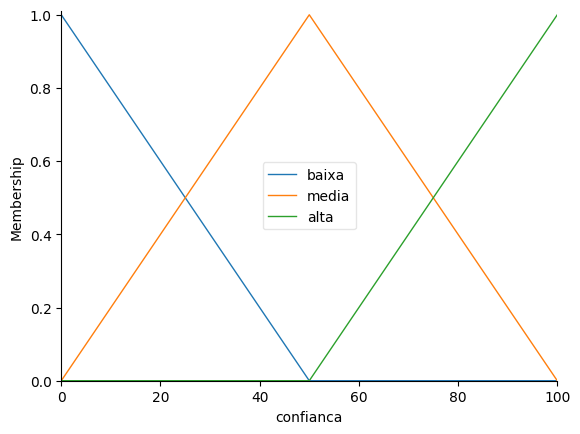

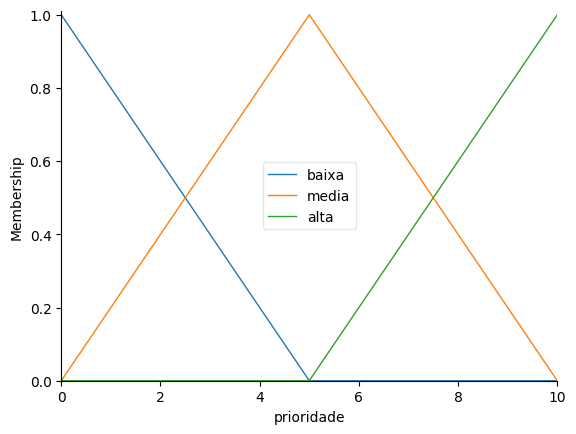

In [4]:
severidade.view()
confianca.view()
prioridade.view()

## Base de regras

9 regras, uma para cada combinacao das 3x3 possibilidades de `severidade` x
`confianca`, entao nenhum ponto do espaco de entrada fica sem regra que o
cubra:

| severidade \ confianca | baixa | media | alta |
| --- | --- | --- | --- |
| **baixa** | baixa | baixa | media |
| **media** | baixa | media | alta |
| **alta** | media | alta | alta |

A leitura e: severidade alta sozinha nao basta (confianca baixa segura a
prioridade em media), e confianca alta sozinha tambem nao (severidade baixa
segura a prioridade em media). So a combinacao dos dois extremos altos leva a
prioridade alta.

In [5]:
regras = [
    ctrl.Rule(severidade["baixa"] & confianca["baixa"], prioridade["baixa"]),
    ctrl.Rule(severidade["baixa"] & confianca["media"], prioridade["baixa"]),
    ctrl.Rule(severidade["baixa"] & confianca["alta"], prioridade["media"]),
    ctrl.Rule(severidade["media"] & confianca["baixa"], prioridade["baixa"]),
    ctrl.Rule(severidade["media"] & confianca["media"], prioridade["media"]),
    ctrl.Rule(severidade["media"] & confianca["alta"], prioridade["alta"]),
    ctrl.Rule(severidade["alta"] & confianca["baixa"], prioridade["media"]),
    ctrl.Rule(severidade["alta"] & confianca["media"], prioridade["alta"]),
    ctrl.Rule(severidade["alta"] & confianca["alta"], prioridade["alta"]),
]

sistema = ctrl.ControlSystem(regras)


def priorizar(sev, conf):
    sim = ctrl.ControlSystemSimulation(sistema)
    sim.input["severidade"] = sev
    sim.input["confianca"] = conf
    sim.compute()
    return sim.output["prioridade"]

## Casos de exemplo

In [6]:
casos = [
    ("scan de porta isolado, sem correlacao", 1, 10),
    ("assinatura de exploit conhecido confirmada", 9, 95),
    ("indicador ambiguo de severidade media", 5, 50),
]
for descricao, sev, conf in casos:
    print(f"{descricao}: severidade={sev} confianca={conf}% "
          f"-> prioridade={priorizar(sev, conf):.2f}")

scan de porta isolado, sem correlacao: severidade=1 confianca=10% -> prioridade=3.27
assinatura de exploit conhecido confirmada: severidade=9 confianca=95% -> prioridade=7.32
indicador ambiguo de severidade media: severidade=5 confianca=50% -> prioridade=5.00


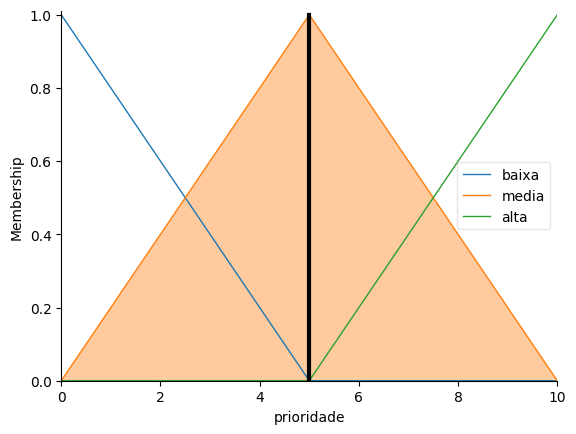

In [7]:
prioridade.view(sim=ctrl.ControlSystemSimulation(sistema))

## Autoverificacao

Extremos opostos do dominio devem produzir prioridades nos extremos opostos,
e o ponto central deve cair perto do meio da escala.

In [8]:
baixa = priorizar(0, 0)
alta = priorizar(10, 100)
media = priorizar(5, 50)

assert baixa < 3, baixa
assert alta > 7, alta
assert 3 <= media <= 7, media
assert alta > baixa
print("autoverificacao ok")

autoverificacao ok
